In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

In [323]:
# importing all dataframes from notebook 2
X_train_df=pd.read_csv('X_train.csv', index_col=False)
X_test_df=pd.read_csv('X_test.csv', index_col=False)
y_train_df=pd.read_csv('y_train.csv', index_col=False)
y_test_df=pd.read_csv('y_test.csv', index_col=False)

In [324]:
# make sure athe datatypes are all numeric
X_train_df.dtypes

rcount                          int64
dialysisrenalendstage           int64
asthma                          int64
irondef                         int64
pneum                           int64
substancedependence             int64
psychologicaldisordermajor      int64
depress                         int64
psychother                      int64
fibrosisandother                int64
malnutrition                    int64
hemo                            int64
secondarydiagnosisnonicd9       int64
gender_M                      float64
facid_B                       float64
facid_C                       float64
facid_D                       float64
facid_E                       float64
bloodureanitro                float64
creatinine                    float64
bmi                           float64
pulse                         float64
sodium                        float64
glucose                       float64
hematocrit                    float64
neutrophils                   float64
dtype: objec

## First model, including all features regradless of the P value. 

In [325]:
# use the training dataset to train the model. 
X_train_wconst=sm.add_constant(X_train_df)
train_model=sm.OLS(y_train_df, X_train_wconst).fit()
train_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           lengthofstay   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     8266.
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:29:12   Log-Likelihood:            -1.0438e+05
No. Observations:               66912   AIC:                         2.088e+05
Df Residuals:                   66885   BIC:                         2.091e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.8180      0.011    169.971      0.000       1.797       1.839
rcount                         1.1494      0.003    397.943      0.000       1.144       1.155
dialysisrenalendstage          0.6759      0.026     25.884      0.000       0.625       0.727
asthma                         0.3612      0.029     12.402      0.000       0.304       0.418
irondef                        0.3454      0.019     18.485      0.000       0.309       0.382
pneum                          0.4492      0.026     17.028      0.000       0.397       0.501
substancedependence            0.5996      0.021     27.949      0.000       0.558       0.642
psychologicaldisordermajor     0.7962      0.019     42.418      0.000       0.759       0.833
depress                        0.3911      0.021     18.327      0.000       0.349       0.433
psychother                     0.5277      0.026     20.096      0.000       0.476       0.579
fibrosisandother               0.9589      0.069     13.950      0.000       0.824       1.094
malnutrition                   0.2734      0.024     11.632      0.000       0.227       0.320
hemo                           1.2287      0.018     69.441      0.000       1.194       1.263
secondarydiagnosisnonicd9      0.0009      0.002      0.401      0.688      -0.003       0.005
gender_M                       0.0793      0.010      8.107      0.000       0.060       0.098
facid_B                       -0.0003      0.011     -0.027      0.978      -0.023       0.022
facid_C                        1.1084      0.026     42.298      0.000       1.057       1.160
facid_D                        0.9373      0.030     31.479      0.000       0.879       0.996
facid_E                        0.7856      0.021     38.023      0.000       0.745       0.826
bloodureanitro                 0.0474      0.002     26.124      0.000       0.044       0.051
creatinine                 -5.654e-05      0.006     -0.009      0.993      -0.012       0.012
bmi                           -0.0058      0.006     -0.962      0.336      -0.018       0.006
pulse                         -0.0062      0.006     -1.086      0.277      -0.018       0.005
sodium                        -0.0076      0.006     -1.265      0.206      -0.019       0.004
glucose                        0.0004      0.006      0.073      0.942      -0.011       0.012
hematocrit                     0.0139      0.005      2.809      0.005       0.004       0.024
neutrophils                    0.1256      0.004     30.993      0.000       0.118       0.134
==============================================================================
Omnibus:                    17355.207   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            50274.

In [326]:
# use the trained model on the test dataset and predict y values. 
X_test_wconst=sm.add_constant(X_test_df)
y_prediction_values=train_model.predict(X_test_wconst)
y_prediction_values
y_test_df


,lengthofstay
0,1
1,2
2,1
3,6
4,4
...,...
32952,7
32953,3
32954,5
32955,1


In [327]:
print(f" The model prediction is inaccurate by {(mean_squared_error(y_prediction_values, y_test_df['lengthofstay']))**0.5:.2f} days")


 The model prediction is inaccurate by 1.13 days


In [328]:
print(f"Standard deviation: {y_test_df.std()}")
print(f"Mean: {y_test_df.mean()}")

Standard deviation: lengthofstay    2.35015
dtype: float64
Mean: lengthofstay    3.983312
dtype: float64


#### Most stays at the hospital range between 1.63 and 6.33. This model is able to predict LOS that is half of the standard deviation. 

#### The R^2 value for this model is 0.76, indicating that 76% of the variance is explained by these features.
#### Performance on the test set matches training performance suggesting the model generalizes well and does not over fit. 

## Second model, 

In [329]:
X_train_df_v2=X_train_df.drop(columns=['secondarydiagnosisnonicd9', 'creatinine', 'bmi', 'pulse', 'sodium', 'glucose'])

In [330]:
X_train_wconst_v2=sm.add_constant(X_train_df_v2)
train_model_v2=sm.OLS(y_train_df, X_train_wconst_v2).fit()
train_model_v2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           lengthofstay   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                 1.075e+04
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:29:12   Log-Likelihood:            -1.0438e+05
No. Observations:               66912   AIC:                         2.088e+05
Df Residuals:                   66891   BIC:                         2.090e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.8196      0.010    188.397      0.000       1.801       1.839
rcount                         1.1494      0.003    397.967      0.000       1.144       1.155
dialysisrenalendstage          0.6759      0.026     25.884      0.000       0.625       0.727
asthma                         0.3614      0.029     12.409      0.000       0.304       0.418
irondef                        0.3456      0.019     18.496      0.000       0.309       0.382
pneum                          0.4490      0.026     17.022      0.000       0.397       0.501
substancedependence            0.5994      0.021     27.943      0.000       0.557       0.641
psychologicaldisordermajor     0.7962      0.019     42.423      0.000       0.759       0.833
depress                        0.3910      0.021     18.326      0.000       0.349       0.433
psychother                     0.5277      0.026     20.097      0.000       0.476       0.579
fibrosisandother               0.9592      0.069     13.955      0.000       0.824       1.094
malnutrition                   0.2735      0.024     11.635      0.000       0.227       0.320
hemo                           1.2286      0.018     69.438      0.000       1.194       1.263
gender_M                       0.0793      0.010      8.114      0.000       0.060       0.099
facid_B                       -0.0002      0.011     -0.020      0.984      -0.023       0.022
facid_C                        1.1083      0.026     42.299      0.000       1.057       1.160
facid_D                        0.9371      0.030     31.475      0.000       0.879       0.995
facid_E                        0.7856      0.021     38.027      0.000       0.745       0.826
bloodureanitro                 0.0474      0.002     26.121      0.000       0.044       0.051
hematocrit                     0.0139      0.005      2.810      0.005       0.004       0.024
neutrophils                    0.1257      0.004     31.000      0.000       0.118       0.134
==============================================================================
Omnibus:                    17351.519   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            50252.246
Skew:                           1.361   Prob(JB):                         0.00
Kurtosis:                       6.259   Cond. No.                         48.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [331]:
X_test_df_v2=X_test_df.drop(columns=['secondarydiagnosisnonicd9', 'creatinine', 'bmi', 'pulse', 'sodium', 'glucose'])

In [332]:
# use the trained model on the test dataset and predict y values. 
X_test_wconst_v2=sm.add_constant(X_test_df_v2)
y_prediction_values_v2=train_model_v2.predict(X_test_wconst_v2)



In [333]:
print(f" The model prediction is inaccurate by {(mean_squared_error(y_prediction_values_v2, y_test_df['lengthofstay']))**0.5:.2f} days")


 The model prediction is inaccurate by 1.13 days


In [334]:
print(f"Standard deviation: {y_test_df.std()}")
print(f"Mean: {y_test_df.mean()}")

Standard deviation: lengthofstay    2.35015
dtype: float64
Mean: lengthofstay    3.983312
dtype: float64


### Even after dropping 6 features, our RMSE and R^2 values have remained constant. this means we can confitm that the features dropped were definately insignificant. 

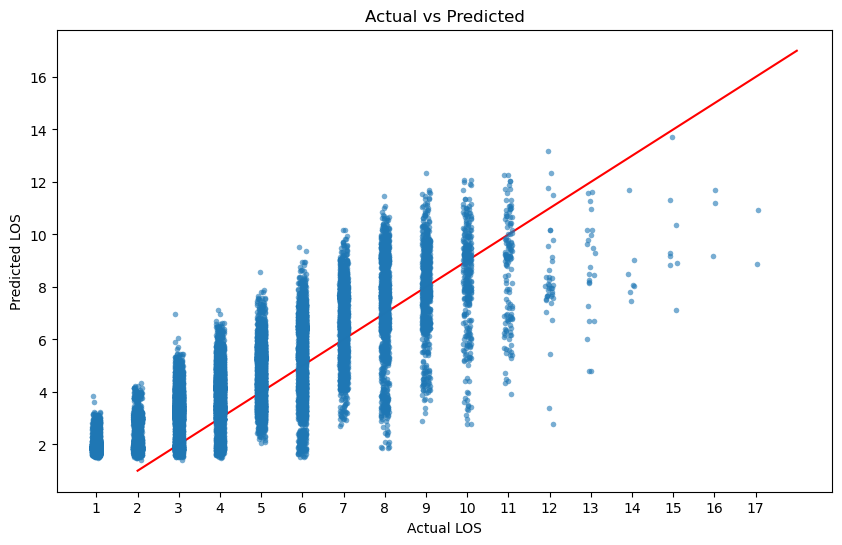

In [335]:
plt.figure(figsize=(10, 6))
sns.stripplot(x=y_test_df['lengthofstay'], y=y_prediction_values_v2, alpha=0.6, jitter=True, size=4, edgecolor=None)
sns.lineplot(x=[y_test_df['lengthofstay'].min(), y_test_df['lengthofstay'].max()], y=[y_test_df['lengthofstay'].min(), y_test_df['lengthofstay'].max()], color='red')
plt.title('Actual vs Predicted')
plt.xlabel('Actual LOS')
plt.ylabel('Predicted LOS')
plt.show()


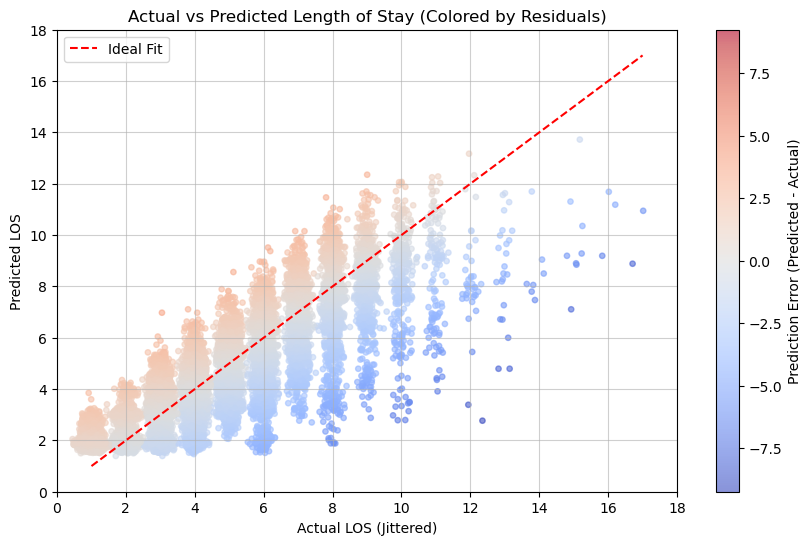

In [336]:
# Calculate residuals (Prediction - Actual)
residuals = y_prediction_values_v2 - y_test_df['lengthofstay']

# Apply small jitter to actual values for visualization
jitter = np.random.normal(0, 0.15, size=len(y_test_df))
x_jittered = y_test_df['lengthofstay'] + jitter

plt.figure(figsize=(10, 6))

scatter = plt.scatter(x_jittered, y_prediction_values_v2, c=residuals, cmap='coolwarm', alpha=0.6, s=15, vmin=-max(abs(residuals)), vmax=max(abs(residuals)))
min_val = min(y_test_df['lengthofstay'].min(), y_prediction_values_v2.min())
max_val = max(y_test_df['lengthofstay'].max(), y_prediction_values_v2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Fit')

cbar = plt.colorbar(scatter)
cbar.set_label('Prediction Error (Predicted - Actual)')

plt.title('Actual vs Predicted Length of Stay (Colored by Residuals)')
plt.xlabel('Actual LOS (Jittered)')
plt.ylabel('Predicted LOS')
plt.xlim(min_val - 1, max_val + 1)
plt.ylim(min_val - 1, max_val + 1)
plt.grid(True, linestyle='-', alpha=0.6)
plt.legend()
plt.show()

## Looking at the plot, we can conclude that since actual LOS is clustered on the lower end, a log transformation of the predicted value could be useful to fix right skewness and underprediction of longer stays. 